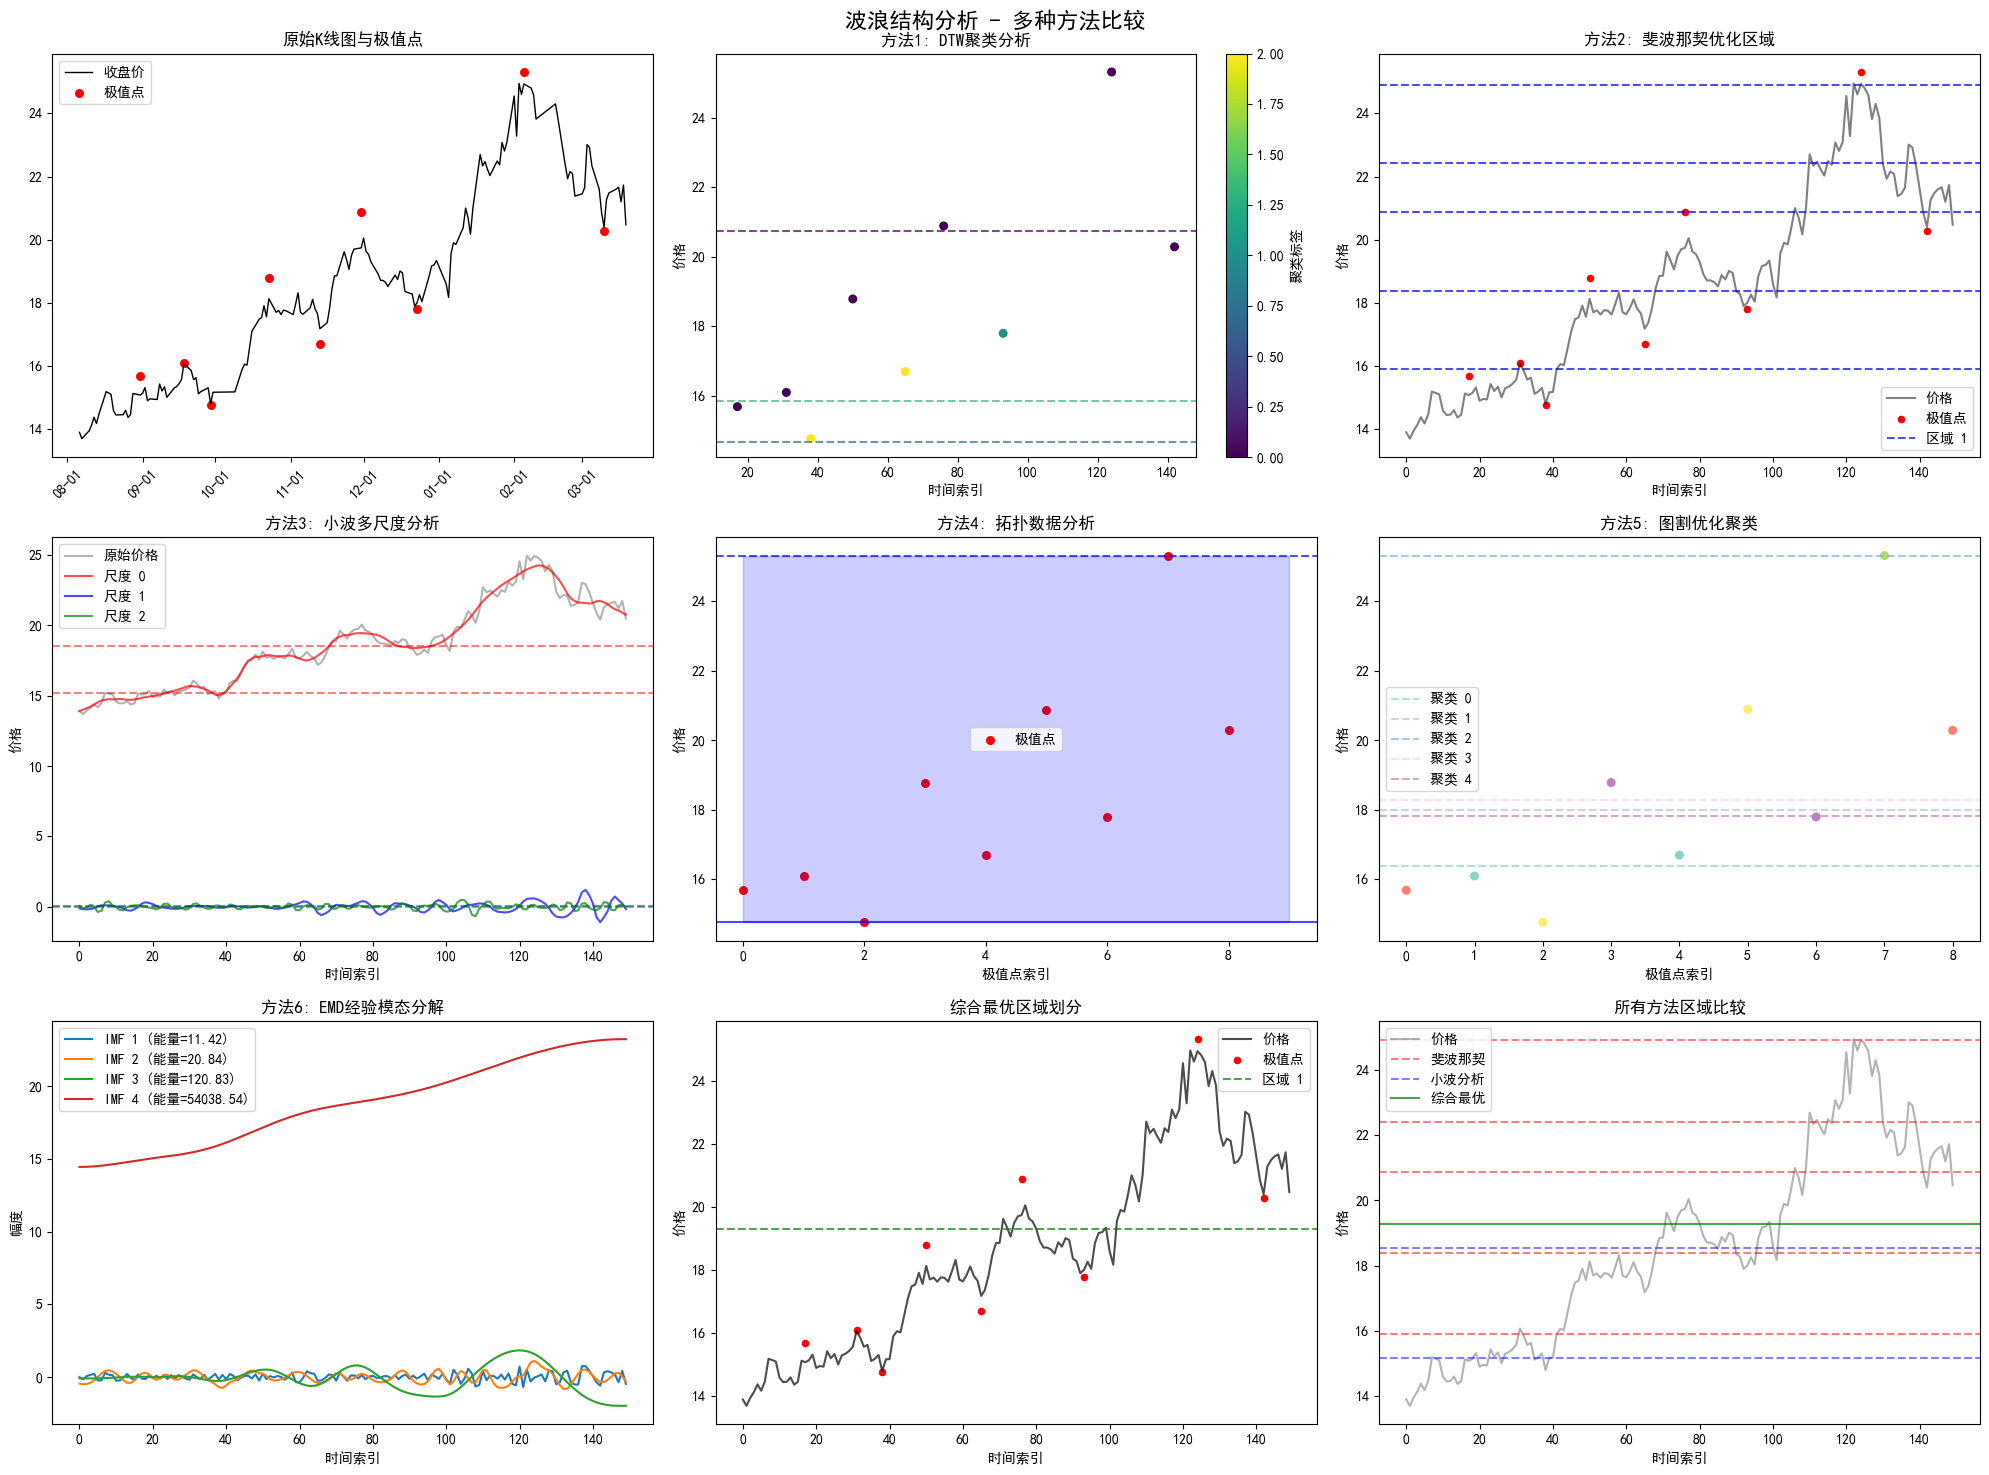

综合最优区域划分:
区域 1: 19.29


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize
from scipy.signal import argrelextrema, find_peaks
from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import kneighbors_graph
import pywt
import networkx as nx
from PyEMD import EMD
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class WaveStructureAnalyzer:
    def __init__(self, df):
        """
        初始化分析器
        df: 包含OHLC数据的DataFrame，列名为小写 ('open', 'high', 'low', 'close')
        """
        self.df = df.copy()
        # 确保索引是日期类型
        if not isinstance(self.df.index, pd.DatetimeIndex):
            try:
                self.df.index = pd.to_datetime(self.df.index)
            except:
                # 如果无法转换为日期，使用整数索引
                self.df.index = range(len(self.df))
        
        self.extreme_points = None
        self.extreme_indices = None
        self.price_series = self.df['close'].values
        
    def find_extreme_points(self, window=10):
        """识别高低点极值点"""
        # 寻找局部高点和低点
        high_indices = argrelextrema(self.df['high'].values, np.greater, order=window)[0]
        low_indices = argrelextrema(self.df['low'].values, np.less, order=window)[0]
        
        # 合并并排序极值点
        extreme_indices = np.sort(np.concatenate([high_indices, low_indices]))
        
        # 提取极值点价格（使用high作为高点，low作为低点）
        extreme_points = []
        for idx in extreme_indices:
            if idx in high_indices:
                extreme_points.append(self.df['high'].iloc[idx])
            else:
                extreme_points.append(self.df['low'].iloc[idx])
        
        self.extreme_points = np.array(extreme_points)
        self.extreme_indices = extreme_indices
        return self.extreme_points
    
    def method1_dtw_clustering(self, n_clusters=3):
        """方法1: 基于动态时间规整的极值点聚类"""
        if self.extreme_points is None or len(self.extreme_points) < 3:
            self.find_extreme_points()
            if len(self.extreme_points) < 3:
                return np.zeros(len(self.extreme_points)), np.array([[0]])
            
        # 提取每个极值点周围的局部模式
        patterns = []
        valid_indices = []
        
        for i in range(1, len(self.extreme_points)-1):
            # 提取前后点的相对位置模式
            pattern = [
                self.extreme_points[i] - self.extreme_points[i-1],  # 前一段幅度
                self.extreme_points[i+1] - self.extreme_points[i],  # 后一段幅度
                self.extreme_indices[i] - self.extreme_indices[i-1],  # 前一时间跨度
                self.extreme_indices[i+1] - self.extreme_indices[i]   # 后一时间跨度
            ]
            patterns.append(pattern)
            valid_indices.append(i)
        
        if len(patterns) == 0:
            return np.zeros(len(self.extreme_points)), np.array([[0]])
        
        patterns = np.array(patterns)
        
        # 标准化模式
        patterns_norm = (patterns - patterns.mean(axis=0)) / (patterns.std(axis=0) + 1e-8)
        
        # 使用K-means聚类
        n_clusters_actual = min(n_clusters, len(patterns))
        kmeans = KMeans(n_clusters=n_clusters_actual, random_state=42)
        clusters = kmeans.fit_predict(patterns_norm)
        
        # 将聚类结果映射回所有极值点
        full_clusters = np.zeros(len(self.extreme_points))
        if len(clusters) > 0:
            full_clusters[1:-1] = clusters  # 中间点有聚类标签
            full_clusters[0] = clusters[0]  # 第一个点
            full_clusters[-1] = clusters[-1]  # 最后一个点
        
        return full_clusters, kmeans.cluster_centers_
    
    def method2_fibonacci_optimization(self, fibonacci_ratios=[0.236, 0.382, 0.5, 0.618, 0.786]):
        """方法2: 基于黄金分割的比例优化"""
        if self.extreme_points is None or len(self.extreme_points) < 2:
            self.find_extreme_points()
            if len(self.extreme_points) < 2:
                return np.array([np.mean(self.price_series)])
            
        points = self.extreme_points
        
        def objective_function(cluster_centers, points):
            """目标函数：最小化点到聚类中心的距离，同时满足斐波那契比例关系"""
            total_distance = 0
            fib_penalty = 0
            
            # 距离项
            for point in points:
                distances = [abs(point - center) for center in cluster_centers]
                total_distance += min(distances)
            
            # 斐波那契比例约束项
            sorted_centers = sorted(cluster_centers)
            price_range = max(points) - min(points)
            
            if price_range > 0:
                for i in range(len(sorted_centers)-1):
                    for j in range(i+1, len(sorted_centers)):
                        ratio = (sorted_centers[j] - sorted_centers[i]) / price_range
                        
                        # 找到最接近的斐波那契比例
                        if fibonacci_ratios:
                            closest_fib = min(fibonacci_ratios, key=lambda x: abs(x - ratio))
                            fib_penalty += abs(ratio - closest_fib) * 10  # 权重可调
            
            return total_distance + fib_penalty
        
        # 初始聚类中心
        n_centers = min(5, len(points))
        initial_centers = np.linspace(min(points), max(points), n_centers)
        
        # 优化
        try:
            result = minimize(
                objective_function, 
                initial_centers, 
                args=(points,),
                method='SLSQP',
                options={'maxiter': 100}
            )
            return result.x
        except:
            return initial_centers
    
    def method3_wavelet_multiscale(self, level=3):
        """方法3: 小波变换多尺度分析 - 修复版本"""
        try:
            # 确保数据长度足够
            if len(self.price_series) < 2**level:
                level = min(level, int(np.log2(len(self.price_series)))) - 1
                if level < 1:
                    return {'level_0': {'signal': self.price_series, 'levels': [np.mean(self.price_series)]}}
            
            # 小波分解
            coeffs = pywt.wavedec(self.price_series, 'db4', level=level)
            
            regions = {}
            
            # 在不同尺度上分析
            for i in range(len(coeffs)):
                # 重建该尺度的信号 - 使用正确的方法
                coeff_list = [coeffs[j] if j == i else np.zeros_like(coeffs[j]) for j in range(len(coeffs))]
                
                # 对于近似系数（第一个系数），使用所有细节系数为零
                if i == 0:
                    for j in range(1, len(coeffs)):
                        coeff_list[j] = np.zeros_like(coeffs[j])
                
                # 重构信号
                reconstructed = pywt.waverec(coeff_list, 'db4')
                
                # 确保长度一致
                if len(reconstructed) > len(self.price_series):
                    reconstructed = reconstructed[:len(self.price_series)]
                elif len(reconstructed) < len(self.price_series):
                    reconstructed = np.pad(reconstructed, (0, len(self.price_series) - len(reconstructed)))
                
                # 找到显著水平
                significant_levels = self._find_significant_levels(reconstructed)
                
                regions[f'level_{i}'] = {
                    'signal': reconstructed,
                    'levels': significant_levels
                }
            
            return regions
        except Exception as e:
            # 如果小波分析失败，返回简单结果
            print(f"小波分析出错: {e}")
            return {'level_0': {'signal': self.price_series, 'levels': [np.mean(self.price_series)]}}
    
    def _find_significant_levels(self, signal, n_bins=50):
        """找出信号中显著的水平区域"""
        try:
            # 使用密度估计找到价格聚集区域
            if len(signal) < 10:
                return [np.mean(signal)]
            
            kde = gaussian_kde(signal)
            x_range = np.linspace(min(signal), max(signal), n_bins)
            density = kde(x_range)
            
            # 找到密度峰值（价格聚集区域）
            peaks, _ = find_peaks(density, height=np.mean(density))
            
            if len(peaks) == 0:
                return [np.mean(signal)]
            
            return x_range[peaks]
        except:
            return [np.mean(signal)]
    
    def method4_topological_analysis(self):
        """方法4: 拓扑数据分析 - 简化版本"""
        if self.extreme_points is None or len(self.extreme_points) < 3:
            self.find_extreme_points()
            if len(self.extreme_points) < 3:
                return [(0, min(self.price_series), max(self.price_series), max(self.price_series)-min(self.price_series))]
        
        # 简化版本：直接分析极值点的分布特征
        points = self.extreme_points
        
        # 计算极值点之间的间隔和幅度
        intervals = np.diff(self.extreme_indices)
        amplitudes = np.diff(points)
        
        # 找出显著的间隔和幅度
        significant_intervals = intervals[intervals > np.mean(intervals)]
        significant_amplitudes = amplitudes[np.abs(amplitudes) > np.mean(np.abs(amplitudes))]
        
        # 创建简化的拓扑特征
        significant_features = []
        if len(significant_amplitudes) > 0:
            # 0维特征：价格区间
            significant_features.append((0, min(points), max(points), max(points)-min(points)))
            
            # 1维特征：主要波动幅度
            for i, amp in enumerate(significant_amplitudes[:3]):  # 取前三个主要幅度
                significant_features.append((1, np.mean(points)-amp/2, np.mean(points)+amp/2, np.abs(amp)))
        
        return significant_features
    
    def method5_graph_cut_optimization(self, n_regions=5):
        """方法5: 图割算法优化"""
        if self.extreme_points is None or len(self.extreme_points) < 2:
            self.find_extreme_points()
            if len(self.extreme_points) < 2:
                return np.zeros(len(self.extreme_points))
            
        points = self.extreme_points.reshape(-1, 1)
        
        # 构建图结构
        n_neighbors = min(5, len(points)-1)
        if n_neighbors < 1:
            return np.zeros(len(points))
        
        graph = kneighbors_graph(points, n_neighbors=n_neighbors, mode='distance')
        
        # 使用谱聚类进行划分
        n_regions_actual = min(n_regions, len(points))
        spectral = SpectralClustering(
            n_clusters=n_regions_actual, 
            affinity='precomputed',
            random_state=42
        )
        
        # 将距离转换为相似度
        similarity_matrix = np.exp(-graph.toarray() / (graph.data.mean() + 1e-8))
        np.fill_diagonal(similarity_matrix, 1)
        
        labels = spectral.fit_predict(similarity_matrix)
        
        return labels
    
    def method6_emd_decomposition(self):
        """方法6: 经验模态分解"""
        try:
            # 执行EMD分解
            emd = EMD()
            imfs = emd(self.price_series)
            
            # 计算每个IMF的能量作为重要性指标
            energies = []
            for imf in imfs:
                energies.append(np.sum(imf**2))
            
            return imfs, energies
        except Exception as e:
            print(f"EMD分解出错: {e}")
            # 返回简单结果
            return [self.price_series - np.mean(self.price_series)], [1.0]
    
    def synthesize_optimal_regions(self):
        """综合所有方法得到最优区域划分"""
        if self.extreme_points is None:
            self.find_extreme_points()
            
        # 收集所有方法的重要水平
        all_levels = []
        
        # 方法2: 斐波那契优化
        try:
            fib_centers = self.method2_fibonacci_optimization()
            all_levels.extend(fib_centers)
        except:
            pass
        
        # 方法3: 小波多尺度分析
        try:
            wavelet_regions = self.method3_wavelet_multiscale(level=3)
            for level_data in wavelet_regions.values():
                all_levels.extend(level_data['levels'])
        except:
            pass
        
        # 方法4: 拓扑分析
        try:
            topological_features = self.method4_topological_analysis()
            for dim, birth, death, persistence in topological_features:
                if dim == 0:  # 连接组件
                    all_levels.extend([birth, death])
        except:
            pass
        
        if not all_levels:
            # 如果没有得到任何水平，使用简单的分位数
            all_levels = np.percentile(self.extreme_points, [25, 50, 75])
        
        # 使用密度估计找到最优聚类中心
        if len(all_levels) > 1:
            kde = gaussian_kde(all_levels)
            x_range = np.linspace(min(self.extreme_points), max(self.extreme_points), 1000)
            density = kde(x_range)
            
            # 找到密度峰值作为最优区域边界
            peaks, _ = find_peaks(density, height=np.mean(density))
            
            if len(peaks) > 0:
                optimal_regions = sorted(x_range[peaks])
            else:
                optimal_regions = [np.mean(self.extreme_points)]
        else:
            optimal_regions = [np.mean(self.extreme_points)]
        
        # 确保区域数量合理
        if len(optimal_regions) > 10:
            # 选择密度最高的10个区域
            peak_densities = density[peaks]
            top_indices = np.argsort(peak_densities)[-10:]
            optimal_regions = sorted(x_range[peaks][top_indices])
        
        return optimal_regions
    
    def plot_all_methods(self):
        """绘制所有方法的图表"""
        if self.extreme_points is None:
            self.find_extreme_points()
            
        # 创建图表
        fig, axes = plt.subplots(3, 3, figsize=(20, 15))
        fig.suptitle('波浪结构分析 - 多种方法比较', fontsize=16)
        
        # 子图1: 原始K线图与极值点
        self._plot_original_kline(axes[0, 0])
        
        # 子图2: 方法1 - DTW聚类
        self._plot_method1(axes[0, 1])
        
        # 子图3: 方法2 - 斐波那契优化
        self._plot_method2(axes[0, 2])
        
        # 子图4: 方法3 - 小波多尺度分析
        self._plot_method3(axes[1, 0])
        
        # 子图5: 方法4 - 拓扑分析
        self._plot_method4(axes[1, 1])
        
        # 子图6: 方法5 - 图割优化
        self._plot_method5(axes[1, 2])
        
        # 子图7: 方法6 - EMD分解
        self._plot_method6(axes[2, 0])
        
        # 子图8: 综合最优区域
        self._plot_synthesized_regions(axes[2, 1])
        
        # 子图9: 所有方法比较
        self._plot_comparison(axes[2, 2])
        
        plt.tight_layout()
        plt.show()
    
    def _plot_original_kline(self, ax):
        """绘制原始K线图和极值点"""
        # 绘制K线图（简化版，使用收盘价）
        ax.plot(self.df.index, self.price_series, 'k-', linewidth=1, label='收盘价')
        
        # 标记极值点
        if self.extreme_indices is not None and len(self.extreme_indices) > 0:
            extreme_dates = self.df.index[self.extreme_indices]
            ax.scatter(extreme_dates, self.extreme_points, color='red', s=30, label='极值点')
        
        ax.set_title('原始K线图与极值点')
        ax.legend()
        
        # 设置日期格式
        if isinstance(self.df.index, pd.DatetimeIndex):
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    def _plot_method1(self, ax):
        """绘制方法1结果"""
        try:
            clusters, centers = self.method1_dtw_clustering()
            
            # 绘制价格和极值点，按聚类着色
            if len(clusters) > 0:
                scatter = ax.scatter(self.extreme_indices, self.extreme_points, c=clusters, cmap='viridis', s=30)
                
                # 绘制聚类中心线
                for i, center in enumerate(centers):
                    if i < len(centers):
                        ax.axhline(y=center[0] * self.extreme_points.std() + self.extreme_points.mean(), 
                                  color=plt.cm.viridis(i/len(centers)), linestyle='--', alpha=0.7)
            
            ax.set_title('方法1: DTW聚类分析')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('价格')
            if len(clusters) > 0:
                plt.colorbar(scatter, ax=ax, label='聚类标签')
        except Exception as e:
            ax.text(0.5, 0.5, f'方法1出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法1: DTW聚类分析 (出错)')
    
    def _plot_method2(self, ax):
        """绘制方法2结果"""
        try:
            fib_centers = self.method2_fibonacci_optimization()
            
            # 绘制价格序列
            ax.plot(self.price_series, 'k-', alpha=0.5, label='价格')
            
            # 绘制极值点
            if self.extreme_indices is not None:
                ax.scatter(self.extreme_indices, self.extreme_points, color='red', s=20, label='极值点')
            
            # 绘制斐波那契优化区域
            for i, center in enumerate(fib_centers):
                ax.axhline(y=center, color='blue', linestyle='--', alpha=0.7, 
                          label=f'区域 {i+1}' if i == 0 else "")
            
            ax.set_title('方法2: 斐波那契优化区域')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'方法2出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法2: 斐波那契优化区域 (出错)')
    
    def _plot_method3(self, ax):
        """绘制方法3结果"""
        try:
            wavelet_regions = self.method3_wavelet_multiscale(level=3)
            
            # 绘制原始价格
            ax.plot(self.price_series, 'k-', alpha=0.3, label='原始价格')
            
            # 绘制不同尺度的小波重建信号
            colors = ['red', 'blue', 'green']
            for i, (key, data) in enumerate(wavelet_regions.items()):
                if i < 3:  # 只显示前3个尺度
                    ax.plot(data['signal'], color=colors[i], alpha=0.7, label=f'尺度 {i}')
                    
                    # 标记显著水平
                    for level in data['levels']:
                        ax.axhline(y=level, color=colors[i], linestyle='--', alpha=0.5)
            
            ax.set_title('方法3: 小波多尺度分析')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'方法3出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法3: 小波多尺度分析 (出错)')
    
    def _plot_method4(self, ax):
        """绘制方法4结果"""
        try:
            topological_features = self.method4_topological_analysis()
            
            # 绘制极值点
            if self.extreme_points is not None:
                ax.scatter(range(len(self.extreme_points)), self.extreme_points, color='red', s=30, label='极值点')
            
            # 绘制拓扑特征
            for dim, birth, death, persistence in topological_features:
                if dim == 0:  # 只显示0维特征（连接组件）
                    ax.axhline(y=birth, color='blue', linestyle='-', alpha=0.7)
                    ax.axhline(y=death, color='blue', linestyle='--', alpha=0.7)
                    ax.fill_between([0, len(self.extreme_points) if self.extreme_points is not None else 100], 
                                   birth, death, alpha=0.2, color='blue')
            
            ax.set_title('方法4: 拓扑数据分析')
            ax.set_xlabel('极值点索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'方法4出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法4: 拓扑数据分析 (出错)')
    
    def _plot_method5(self, ax):
        """绘制方法5结果"""
        try:
            labels = self.method5_graph_cut_optimization()
            
            # 绘制极值点，按图割结果着色
            if len(labels) > 0:
                scatter = ax.scatter(range(len(self.extreme_points)), self.extreme_points, c=labels, cmap='Set3', s=30)
                
                # 计算每个聚类的中心
                unique_labels = np.unique(labels)
                for label in unique_labels:
                    cluster_points = self.extreme_points[labels == label]
                    if len(cluster_points) > 0:
                        center = np.mean(cluster_points)
                        ax.axhline(y=center, color=plt.cm.Set3(label/len(unique_labels)), 
                                  linestyle='--', alpha=0.7, label=f'聚类 {label}')
            
            ax.set_title('方法5: 图割优化聚类')
            ax.set_xlabel('极值点索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'方法5出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法5: 图割优化聚类 (出错)')
    
    def _plot_method6(self, ax):
        """绘制方法6结果"""
        try:
            imfs, energies = self.method6_emd_decomposition()
            
            # 绘制前几个IMF
            for i in range(min(4, len(imfs))):
                ax.plot(imfs[i], label=f'IMF {i+1} (能量={energies[i]:.2f})')
            
            ax.set_title('方法6: EMD经验模态分解')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('幅度')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'方法6出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('方法6: EMD经验模态分解 (出错)')
    
    def _plot_synthesized_regions(self, ax):
        """绘制综合最优区域"""
        try:
            optimal_regions = self.synthesize_optimal_regions()
            
            # 绘制价格序列
            ax.plot(self.price_series, 'k-', alpha=0.7, label='价格')
            
            # 绘制极值点
            if self.extreme_indices is not None:
                ax.scatter(self.extreme_indices, self.extreme_points, color='red', s=20, label='极值点')
            
            # 绘制最优区域
            for i, region in enumerate(optimal_regions):
                ax.axhline(y=region, color='green', linestyle='--', alpha=0.7,
                          label=f'区域 {i+1}' if i == 0 else "")
            
            ax.set_title('综合最优区域划分')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'综合区域出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('综合最优区域划分 (出错)')
    
    def _plot_comparison(self, ax):
        """绘制所有方法比较"""
        try:
            # 绘制价格序列
            ax.plot(self.price_series, 'k-', alpha=0.3, label='价格')
            
            # 方法2: 斐波那契优化
            try:
                fib_centers = self.method2_fibonacci_optimization()
                for center in fib_centers:
                    ax.axhline(y=center, color='red', linestyle='--', alpha=0.5, label='斐波那契' if center == fib_centers[0] else "")
            except:
                pass
            
            # 方法3: 小波多尺度分析
            try:
                wavelet_regions = self.method3_wavelet_multiscale(level=3)
                for i, (key, data) in enumerate(wavelet_regions.items()):
                    if i == 0:  # 只显示第一个尺度的水平
                        for level in data['levels']:
                            ax.axhline(y=level, color='blue', linestyle='--', alpha=0.5, 
                                      label='小波分析' if level == data['levels'][0] else "")
                        break
            except:
                pass
            
            # 综合最优区域
            try:
                optimal_regions = self.synthesize_optimal_regions()
                for region in optimal_regions:
                    ax.axhline(y=region, color='green', linestyle='-', alpha=0.7, 
                              label='综合最优' if region == optimal_regions[0] else "")
            except:
                pass
            
            ax.set_title('所有方法区域比较')
            ax.set_xlabel('时间索引')
            ax.set_ylabel('价格')
            ax.legend()
        except Exception as e:
            ax.text(0.5, 0.5, f'比较图出错: {e}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('所有方法区域比较 (出错)')



#import os
from pathlib import Path
import os
# 使用示例
if __name__ == "__main__":
    # 这里应该是您的数据加载代码
    ts_code =  "000001.SZ"
    analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
    csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"    
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=150)
    
    # 初始化分析器
    analyzer = WaveStructureAnalyzer(df)
    
    # 执行所有分析并绘制图表
    analyzer.plot_all_methods()
    
    # 打印综合最优区域
    optimal_regions = analyzer.synthesize_optimal_regions()
    print("综合最优区域划分:")
    for i, region in enumerate(optimal_regions):
        print(f"区域 {i+1}: {region:.2f}")